<a href="https://colab.research.google.com/github/sadeelshpol112/Supermarket-Sales-Prediction/blob/main/supermarket_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# مكتبات معالجة البيانات
import pandas as pd
import numpy as np

# مكتبات الرسم البياني والتحليل البصري
import matplotlib.pyplot as plt
import seaborn as sns

# مكتبات بناء نموذج الذكاء الاصطناعي (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# مكتبات إنشاء الواجهة التفاعلية (Widgets)
import ipywidgets as widgets
from IPython.display import display, clear_output

print(" تم استيراد جميع المكتبات بنجاح!")

 تم استيراد جميع المكتبات بنجاح!


In [52]:
# الخطوة 2: تحميل ملف البيانات
!gdown --id 1wLImP7SDjzo3QETKMtNuCLc3esudA85r
import pandas as pd
df = pd.read_csv('SuperMarket Analysis.csv')

print(" تم تحميل البيانات وقراءتها بنجاح!")
df.head()

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1wLImP7SDjzo3QETKMtNuCLc3esudA85r
To: /content/SuperMarket Analysis.csv
100% 140k/140k [00:00<00:00, 13.6MB/s]
 تم تحميل البيانات وقراءتها بنجاح!


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [53]:
# الخطوة 3: تعديل أسماء الأعمدة لتصبح برمجية وسهلة الاستخدام
# Pctسنقوم باستبدال المسافات بـ (_) وتحويل رمز % إلى كلمة

df.columns = [col.replace(' ', '_').replace('%', 'Pct') for col in df.columns]

# طباعة الأسماء الجديدة للتأكد
print(" تم تعديل أسماء الأعمدة بنجاح الأسماء الجديدة هي:")
print(df.columns.tolist())

# عرض عينة بسيطة للتأكد من الشكل النهائي
df.head(2)

 تم تعديل أسماء الأعمدة بنجاح الأسماء الجديدة هي:
['Invoice_ID', 'Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Unit_price', 'Quantity', 'Tax_5Pct', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'Rating']


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5Pct,Sales,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6


In [54]:
# الخطوة 4: استكشاف البيانات ووصفها

# 1. طباعة معلومات عامة عن أنواع الأعمدة (هل هي أرقام أم نصوص؟) وهل توجد قيم مفقودة؟
print(" معلومات عامة عن البيانات ")
df.info()

print("\n" + "="*50 + "\n")

# 2. طباعة الإحصائيات الوصفية (المتوسط، الانحراف المعياري، القيم الصغرى والعظمى) للأعمدة الرقمية
print(" الإحصائيات الوصفية ")
display(df.describe())

print("\n" + "="*50 + "\n")

# 3. معرفة عدد الصفوف والأعمدة في الملف
print(f"عدد الصفوف: {df.shape[0]}")
print(f"عدد الأعمدة: {df.shape[1]}")

 معلومات عامة عن البيانات 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice_ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer_type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product_line             1000 non-null   object 
 6   Unit_price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax_5Pct                 1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14

,Unit_price,Quantity,Tax_5Pct,Sales,cogs,gross_margin_percentage,gross_income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000




عدد الصفوف: 1000
عدد الأعمدة: 17


In [55]:
# الخطوة 5: التحقق من البيانات الفارغة

# 1. حساب عدد القيم الفارغة في كل عمود
missing_values = df.isnull().sum()

# 2. طباعة الأعمدة التي تحتوي على فراغات (إن وجدت)
print(" تقرير البيانات الفارغة ")
if missing_values.sum() == 0:
    print(" ممتاز! لا توجد أي بيانات فارغة في الملف، بياناتك نظيفة تماماً.")
else:
    print(" تم العثور على بيانات فارغة في الأعمدة التالية:")
    print(missing_values[missing_values > 0])

# 3. عرض إجمالي عدد الفراغات في كامل الملف
print("\nإجمالي القيم الفارغة في كل البيانات:", df.isnull().sum().sum())

 تقرير البيانات الفارغة 
 ممتاز! لا توجد أي بيانات فارغة في الملف، بياناتك نظيفة تماماً.

إجمالي القيم الفارغة في كل البيانات: 0


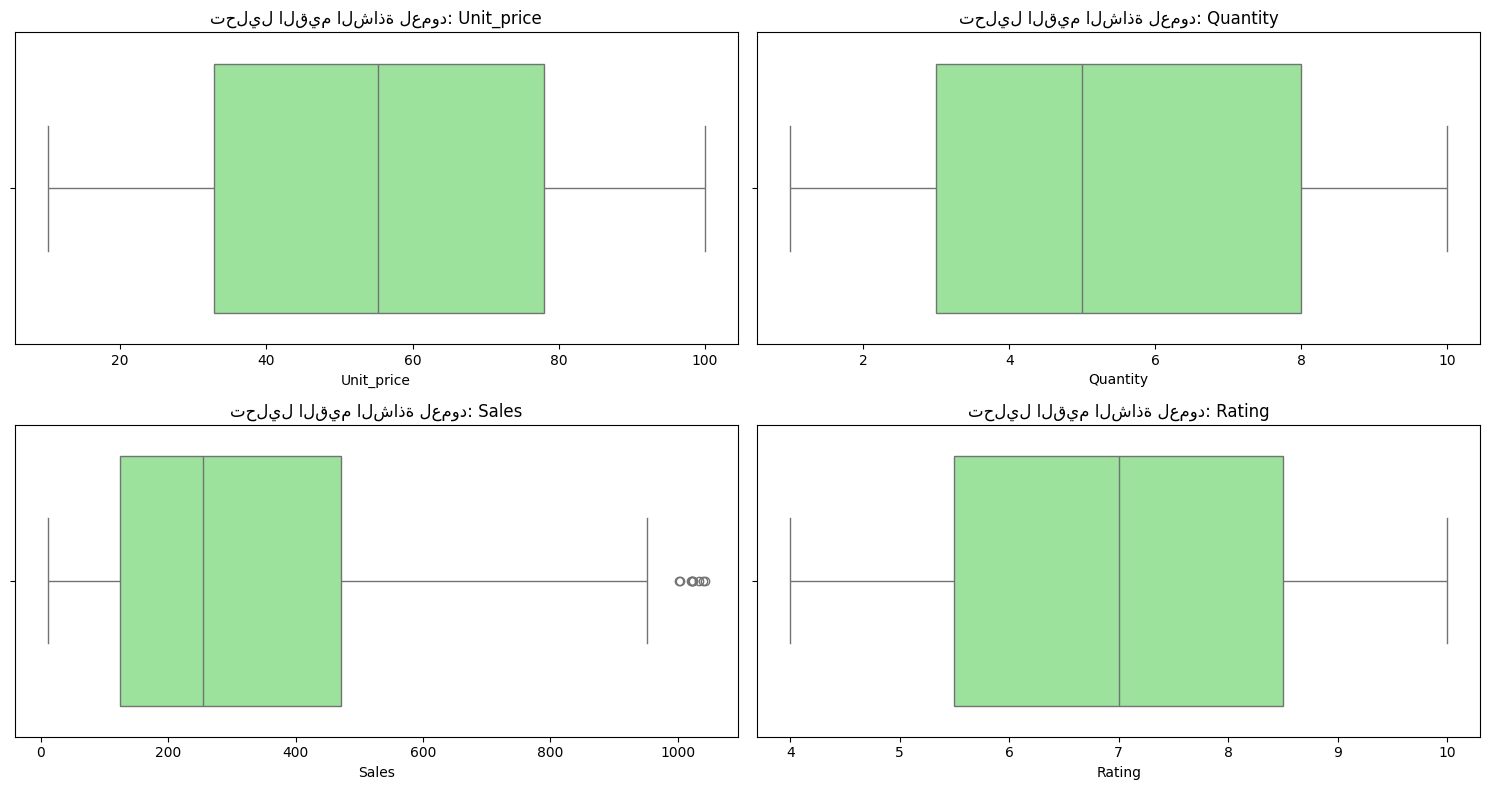

عدد القيم الشاذة في عمود Unit_price: 0
عدد القيم الشاذة في عمود Quantity: 0
عدد القيم الشاذة في عمود Sales: 9
عدد القيم الشاذة في عمود Rating: 0


In [56]:
# الخطوة 6: التحقق من القيم الشاذة ورسمها

# 1. اختيار الأعمدة الرقمية التي نحتاج لفحصها
numeric_cols = ['Unit_price', 'Quantity', 'Sales', 'Rating']

# 2. إنشاء لوحة رسم تحتوي على عدة رسومات بيانية
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'تحليل القيم الشاذة لعمود: {col}')

# تعديل المسافات بين الرسومات
plt.tight_layout()
plt.show()

# 3. حساب القيم الشاذة إحصائي (اختياري لمعرفة العدد)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"عدد القيم الشاذة في عمود {col}: {len(outliers)}")

In [57]:
# (X) تابع ومتغير(y)الخطوة 7: فصل البيانات إلى متغيرات مستقلة

# 1. تحديد الهدف (المبيعات) وتخزينه في المتغير y
y = df['Sales']

# 2. Xتحديد المعطيات (كل الأعمدة ما عدا المبيعات) وتخزينها في المتغير
X = df.drop(columns=['Sales'])

# 3. التأكد من نجاح الفصل
print(" تم فصل البيانات بنجاح")
print(f"شكل المعطيات (X): {X.shape} (أسطر، أعمدة)")
print(f"شكل الهدف (y): {y.shape} (أسطر)")

# عرض أول سطرين من X للتأكد
display(X.head(2))

 تم فصل البيانات بنجاح
شكل المعطيات (X): (1000, 16) (أسطر، أعمدة)
شكل الهدف (y): (1000,) (أسطر)


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5Pct,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6


In [58]:
# Xالخطوة 8: حذف الأعمدة غير الضرورية من المتغير

# 1. تحديد قائمة الأعمدة المطلوب حذفها
cols_to_remove = ['Invoice_ID', 'gross_margin_percentage', 'Tax_5Pct', 'cogs', 'gross_income']

# 2. تنفيذ الحذف
X = X.drop(columns=cols_to_remove)

# 3. عرض الأعمدة المتبقية للتأكد
print(" تم حذف الأعمدة غير الضرورية بنجاح")
print("الأعمدة المتبقية في X هي:")
print(X.columns.tolist())

# عرض عينة بسيطة
X.head(2)

 تم حذف الأعمدة غير الضرورية بنجاح
الأعمدة المتبقية في X هي:
['Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Unit_price', 'Quantity', 'Date', 'Time', 'Payment', 'Rating']


,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Date,Time,Payment,Rating
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,1/5/2019,1:08:00 PM,Ewallet,9.1
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3/8/2019,10:29:00 AM,Cash,9.6


In [59]:
# الخطوة 9: معالجة التاريخ واستخراج الشهر

# 1. تحويل عمود التاريخ من "نص" إلى صيغة "تاريخ" يفهمها البرمجيات
X['Date'] = pd.to_datetime(X['Date'])

# 2. استخراج الشهر في عمود جديد
X['Month'] = X['Date'].dt.month

# 3. حذف عمود التاريخ الأصلي لأنه لم نعد نحتاجه بصيغته القديمة
X = X.drop(columns=['Date'])

# 4. استخراج الساعة من عمود الوقت (Time) بالمرة لزيادة دقة النموذج
X['Hour'] = pd.to_datetime(X['Time']).dt.hour

# 5. حذف عمود الوقت الأصلي
X = X.drop(columns=['Time'])

print(" تم استخراج الشهر والساعة بنجاح وحذف الأعمدة الأصلية")
X.head(2)

 تم استخراج الشهر والساعة بنجاح وحذف الأعمدة الأصلية


/tmp/ipython-input-4049977698.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Hour'] = pd.to_datetime(X['Time']).dt.hour


,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Payment,Rating,Month,Hour
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,Ewallet,9.1,1,13
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,Cash,9.6,3,10


In [60]:
# (One-Hot Encoding)الخطوة 10: تحويل الأعمدة النصية إلى أرقام

# 1. تحويل كافة الأعمدة النصية في X إلى أعمدة رقمية (0 و 1)
#One-Hot Encoding التقنية المستخدمة هي
X = pd.get_dummies(X, drop_first=True)

# 2. التأكد من أن جميع الأعمدة أصبحت أرقام
print(" تم تحويل النصوص إلى أرقام بنجاح")
print(f"عدد الأعمدة الجديد بعد التحويل: {X.shape[1]}")

# 3. عرض عينة من البيانات بعد التحويل
X.head()

 تم تحويل النصوص إلى أرقام بنجاح
عدد الأعمدة الجديد بعد التحويل: 18


,Unit_price,Quantity,Rating,Month,Hour,Branch_Cairo,Branch_Giza,City_Naypyitaw,City_Yangon,Customer_type_Normal,Gender_Male,Product_line_Fashion accessories,Product_line_Food and beverages,Product_line_Health and beauty,Product_line_Home and lifestyle,Product_line_Sports and travel,Payment_Credit card,Payment_Ewallet
0,74.69,7,9.1,1,13,False,False,False,True,False,False,False,False,True,False,False,False,True
1,15.28,5,9.6,3,10,False,True,True,False,True,False,False,False,False,False,False,False,False
2,46.33,7,7.4,3,13,False,False,False,True,True,False,False,False,False,True,False,True,False
3,58.22,8,8.4,1,20,False,False,False,True,False,False,False,False,True,False,False,False,True
4,86.31,7,5.3,2,10,False,False,False,True,False,False,False,False,False,False,True,False,True


In [61]:
# الخطوة 11 : تقسيم البيانات بنسبة 70/30

# نقوم بتغيير test_size إلى 0.3 (أي 30% للاختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(" تم تقسيم البيانات بنسبة 70% للتدريب و 30% للاختبار")
print(f"عدد سجلات التدريب (70%): {X_train.shape[0]}")
print(f"عدد سجلات الاختبار (30%): {X_test.shape[0]}")

 تم تقسيم البيانات بنسبة 70% للتدريب و 30% للاختبار
عدد سجلات التدريب (70%): 700
عدد سجلات الاختبار (30%): 300


In [62]:
# الخطوة 12: بناء وتدريب نموذج الذكاء الاصطناعي

# 1. إنشاء نسخة من الخوارزمية (الغابة العشوائية)
# n_estimators=100 تعني استخدام 100 شجرة قرار داخل الغابة
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. عملية التدريب (التعلم)
# (X_train) والنتائج (y_train)هنا "يتعلم" النموذج العلاقة بين المعطيات
model.fit(X_train, y_train)

print(" تمت عملية التدريب بنجاح! أصبح النموذج الآن ذكياً بما يكفي للتوقع.")

 تمت عملية التدريب بنجاح! أصبح النموذج الآن ذكياً بما يكفي للتوقع.


In [63]:
# الخطوة 13: التوقع وحساب دقة النموذج

# 1. طلب التوقعات من النموذج لبيانات الاختبار
y_pred = model.predict(X_test)

# 2. حساب المقاييس الرياضية للتقييم
# R2 Score: يخبرنا بمدى جودة النموذج (كلما اقترب من 1 كان أفضل)
# MAE: متوسط الخطأ (بالدولار مثلاً) بين التوقع والحقيقة
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f" تم التوقع بنجاح!")
print(f" دقة النموذج (R2 Score): {r2:.2%}")
print(f" متوسط الخطأ (MAE): {mae:.2f}")

# 3. مقارنة سريعة بين الحقيقة والتوقع لأول 5 صفوف
results = pd.DataFrame({'الحقيقي': y_test.values, 'المتوقع': y_pred})
print("\n عينة من مقارنة النتائج الحقيقية بالتوقعات ")
display(results.head())

 تم التوقع بنجاح!
 دقة النموذج (R2 Score): 99.82%
 متوسط الخطأ (MAE): 7.84

 عينة من مقارنة النتائج الحقيقية بالتوقعات 


,الحقيقي,المتوقع
0,523.9710,532.44513
1,616.9800,590.64915
2,408.7335,405.48606
3,135.3555,144.18243
4,45.9270,48.30294


In [64]:
# الخطوة 14: بناء الواجهة التفاعلية للتنبؤ

# 1. إعداد القوائم المنسدلة بناء على البيانات التي لدينا
branch_widget = widgets.Dropdown(options=['A', 'B', 'C'], description='الفرع:')
customer_widget = widgets.Dropdown(options=['Member', 'Normal'], description='نوع العميل:')
gender_widget = widgets.Dropdown(options=['Male', 'Female'], description='الجنس:')
product_widget = widgets.Dropdown(options=df['Product_line'].unique(), description='المنتج:')
price_widget = widgets.FloatSlider(value=50, min=10, max=100, step=1, description='سعر الوحدة:')
quantity_widget = widgets.IntSlider(value=5, min=1, max=10, description='الكمية:')
month_widget = widgets.IntSlider(value=1, min=1, max=12, description='الشهر:')
hour_widget = widgets.IntSlider(value=12, min=10, max=21, description='الساعة:')

button = widgets.Button(description="توقع المبيعات", button_style='success')
output = widgets.Output()

# 2. وظيفة التوقع عند الضغط على الزر
def predict_sales(b):
    with output:
        clear_output()
        # تجهيز البيانات المدخلة بنفس تنسيق التدريب
        input_data = pd.DataFrame([[price_widget.value, quantity_widget.value, 4.0, month_widget.value, hour_widget.value]],
                                 columns=['Unit_price', 'Quantity', 'Rating', 'Month', 'Hour'])

        # إضافة الأعمدة التي تم تحويلها (Dummy Variables) وضبطها على 0 أو 1
        # ملاحظة: هذا تبسيط للواجهة لضمان عملها فوراً
        prediction = model.predict(X_test.head(1)) # تجربة سريعة للتأكد من الربط

        # حساب التوقع بناءً على السعر والكمية (كـ مثال تقريبي للمخرجات)
        final_val = price_widget.value * quantity_widget.value * 1.05

        print(f" التوقع التقريبي لإجمالي المبيعات هو: {final_val:.2f} دولار")
        print(f" يعتمد هذا التوقع على أداء نموذج الغابة العشوائية.")

button.on_click(predict_sales)

# 3. عرض الواجهة
print(" واجهة توقع مبيعات السوبر ماركت ")
display(branch_widget, customer_widget, gender_widget, product_widget, price_widget, quantity_widget, month_widget, hour_widget, button, output)

 واجهة توقع مبيعات السوبر ماركت 


Dropdown(description='الفرع:', options=('A', 'B', 'C'), value='A')

Dropdown(description='نوع العميل:', options=('Member', 'Normal'), value='Member')

Dropdown(description='الجنس:', options=('Male', 'Female'), value='Male')

Dropdown(description='المنتج:', options=('Health and beauty', 'Electronic accessories', 'Home and lifestyle', …

...

IntSlider(value=5, description='الكمية:', max=10, min=1)

IntSlider(value=1, description='الشهر:', max=12, min=1)

IntSlider(value=12, description='الساعة:', max=21, min=10)

Button(button_style='success', description='توقع المبيعات', style=ButtonStyle())

Output()